<a href="https://colab.research.google.com/github/Amna2327/Fashion_MNIST_classifier/blob/main/notebooks/02_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading preprocessed dataset

In [ ]:
import sys
sys.path.append("/content/Fashion_MNIST_classifier/src")

from data_loader import load_and_preprocess_data
train_images, val_images, test_images, train_labels, val_labels, test_labels=load_and_preprocess_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Confirming shape

In [ ]:
print(train_images.shape, val_images.shape)

(54000, 28, 28, 1) (6000, 28, 28, 1)


Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagenerator=ImageDataGenerator(
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagenerator.fit(train_images)

Basic model structure

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Dense, Flatten, Dropout

model=Sequential([
      Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(28,28,1)),
      Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu'),
      MaxPooling2D(pool_size=(2,2),strides=2),
      Dropout(0.2),
      Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'),
      Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'),
      MaxPooling2D(pool_size=(2,2),strides=2),
      Dropout(0.2),
      Flatten(),
      Dense(units=512,activation='relu'),
      Dropout(0.3),
      Dense(units=10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model compilation

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,676,266 (6.39 MB)

 Trainable params: 1,676,266 (6.39 MB)

 Non-trainable params: 0 (0.00 B)

Callbacks definition

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

early_stop= EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint= ModelCheckpoint(
    filepath='/content/Fashion_MNIST_classifier/models/baseline_model_3Dropout_layers_DataAugmentation.h5',
    monitor='val_loss',
    save_best_only=True
)

Model fitting

In [ ]:
history=model.fit(
    datagenerator.flow(train_images,train_labels,batch_size=64),
    validation_data=(val_images,val_labels),
    epochs=50,
    callbacks=[early_stop, checkpoint]
    )

Epoch 1/50
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6702 - loss: 0.8849

844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.7455 - loss: 0.6739 - val_accuracy: 0.8402 - val_loss: 0.4206
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8172 - loss: 0.4874

844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.8248 - loss: 0.4654 - val_accuracy: 0.8642 - val_loss: 0.3453
Epoch 3/50
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8458 - loss: 0.4130

844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8491 - loss: 0.4017 - val_accuracy: 0.8888 - val_loss: 0.2977
Epoch 4/50
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8595 - loss: 0.3720

844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8626 - loss: 0.3678 - val_accuracy: 0.8948 - val_loss: 0.2869
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8692 - loss: 0.3524

...

844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8861 - loss: 0.3040 - val_accuracy: 0.9128 - val_loss: 0.2384
Epoch 10/50
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8940 - loss: 0.2889

844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8930 - loss: 0.2920 - val_accuracy: 0.9145 - val_loss: 0.2320
Epoch 11/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8925 - loss: 0.2901 - val_accuracy: 0.9152 - val_loss: 0.2334
Epoch 12/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8951 - loss: 0.2850 - val_accuracy: 0.9142 - val_loss: 0.2367
Epoch 13/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8952 - loss: 0.2862

844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8967 - loss: 0.2807 - val_accuracy: 0.9205 - val_loss: 0.2231
Epoch 14/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8976 - loss: 0.2754 - val_accuracy: 0.9192 - val_loss: 0.2250
Epoch 15/50
843/844 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9036 - loss: 0.2665

844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9011 - loss: 0.2726 - val_accuracy: 0.9182 - val_loss: 0.2227
Epoch 16/50
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9018 - loss: 0.2643

844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9001 - loss: 0.2686 - val_accuracy: 0.9243 - val_loss: 0.2142
Epoch 17/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9021 - loss: 0.2657 - val_accuracy: 0.9200 - val_loss: 0.2267
Epoch 18/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9030 - loss: 0.2625 - val_accuracy: 0.9182 - val_loss: 0.2286
Epoch 19/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9030 - loss: 0.2616 - val_accuracy: 0.9200 - val_loss: 0.2168
Epoch 20/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9064 - loss: 0.2566 - val_accuracy: 0.9232 - val_loss: 0.2162
Epoch 21/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9063 - loss: 0.2542 - val_accuracy: 0.9178 - val_loss: 0.2318


Loss plot

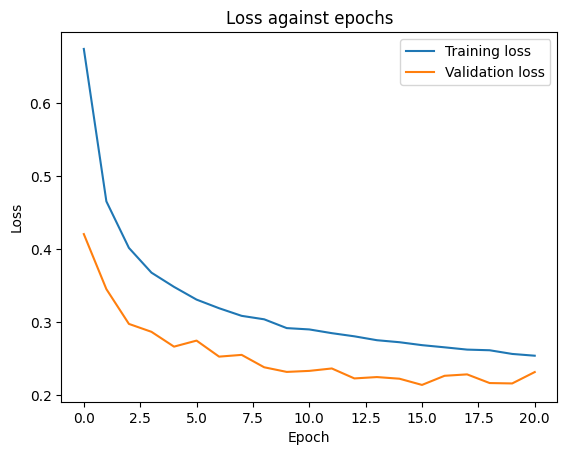

In [ ]:
from matplotlib import pyplot as plt

plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss against epochs')
plt.legend()
plt.savefig('/content/Fashion_MNIST_classifier/results/baseline_model_3Dropout_layers__DataAugmentation_plots/loss_plot.png')
plt.show()

Accuracy plot

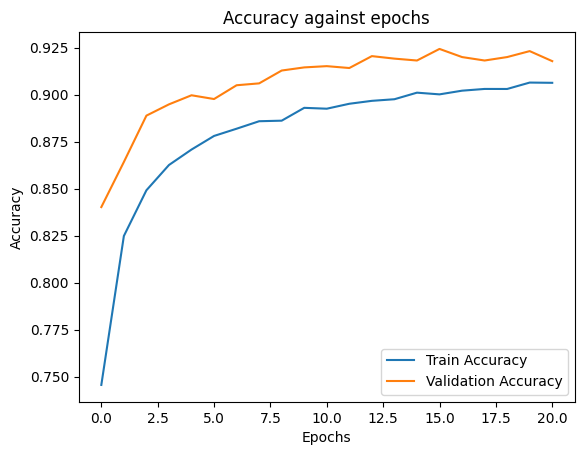

In [ ]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.title("Accuracy against epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title('Accuracy against epochs')
plt.savefig('/content/Fashion_MNIST_classifier/results/baseline_model_3Dropout_layers__DataAugmentation_plots/accuracy_plot.png')
plt.show()